# 카테고리 × 랭킹 윈도우 워드클라우드 비교

**작성일:** 2026-05-26

단일 run의 `normalized.json`에서 **상품 랭킹(`sub_pan=product`)**만 사용합니다.
각 카테고리는 **별도 셀**에서 윈도우마다 **세로 1열·큰 패널**로 워드클라우드를 표시합니다.


## 사전 준비

```bash
source .venv/bin/activate
pip install wordcloud matplotlib pandas jupyter
```


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

import wordcloud_lab as wl

RUNS_DIR = PROJECT_ROOT / "runs"
OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "output" / "product_name_window_wordcloud"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RUN_DIR: Path | None = None
WINDOW_ORDER = list(wl.WINDOW_DISPLAY_ORDER)
COLUMN_FIGSIZE = (14.0, 6.5)

In [2]:
run_dir = wl.resolve_run_dir(RUNS_DIR, RUN_DIR)
items = wl.load_items(run_dir)
product_only = wl.product_items(items)

font_path, _ = wl.init_fonts()
if font_path:
    print(f"font: {font_path}")
print(f"run: {run_dir.name}")
print(f"상품 행: {len(product_only):,} / 전체 {len(items):,}")

font: /System/Library/Fonts/Supplemental/AppleGothic.ttf
run: 20260527_172433
상품 행: 12,000 / 전체 13,747


In [3]:
cw_counters, ubiquitous_tokens = wl.build_category_window_counters(product_only)

rows = []
for (code, label, wid, wlabel), ctr in sorted(cw_counters.items(), key=lambda x: (x[0][0], x[0][2])):
    rows.append({
        "category_code": code,
        "category_label": label,
        "window_id": wid,
        "window_label": wlabel,
        "token_occurrences": sum(ctr.values()),
        "unique_tokens": len(ctr),
    })
summary_df = pd.DataFrame(rows)
print(f"패널 수: {len(summary_df)}, 자동 포괄어: {len(ubiquitous_tokens)}")
summary_df

패널 수: 16, 자동 포괄어: 18


,category_code,category_label,window_id,window_label,token_occurrences,unique_tokens
0,001000,상의,1d,일간,313,164
1,001000,상의,1m,월간,301,159
2,001000,상의,1w,주간,6797,644
3,001000,상의,rt,실시간,2318,579
4,002000,아우터,1d,일간,401,168
5,002000,아우터,1m,월간,374,148
6,002000,아우터,1w,주간,8115,783
7,002000,아우터,rt,실시간,2792,682
8,003000,바지,1d,일간,409,141
9,003000,바지,1m,월간,401,146


## 카테고리별 윈도우 워드클라우드

윈도우(일간 → 주간 → 실시간 → 월간)마다 **세로 1열**로 큰 워드클라우드를 표시합니다.


In [4]:
window_panels_by_cat = wl.build_window_panels_by_category(cw_counters, WINDOW_ORDER)
print("카테고리:", {c: lbl for c, (lbl, _) in window_panels_by_cat.items()})

카테고리: {'001000': '상의', '002000': '아우터', '003000': '바지', '004000': '가방'}


### 상의 (`001000`)


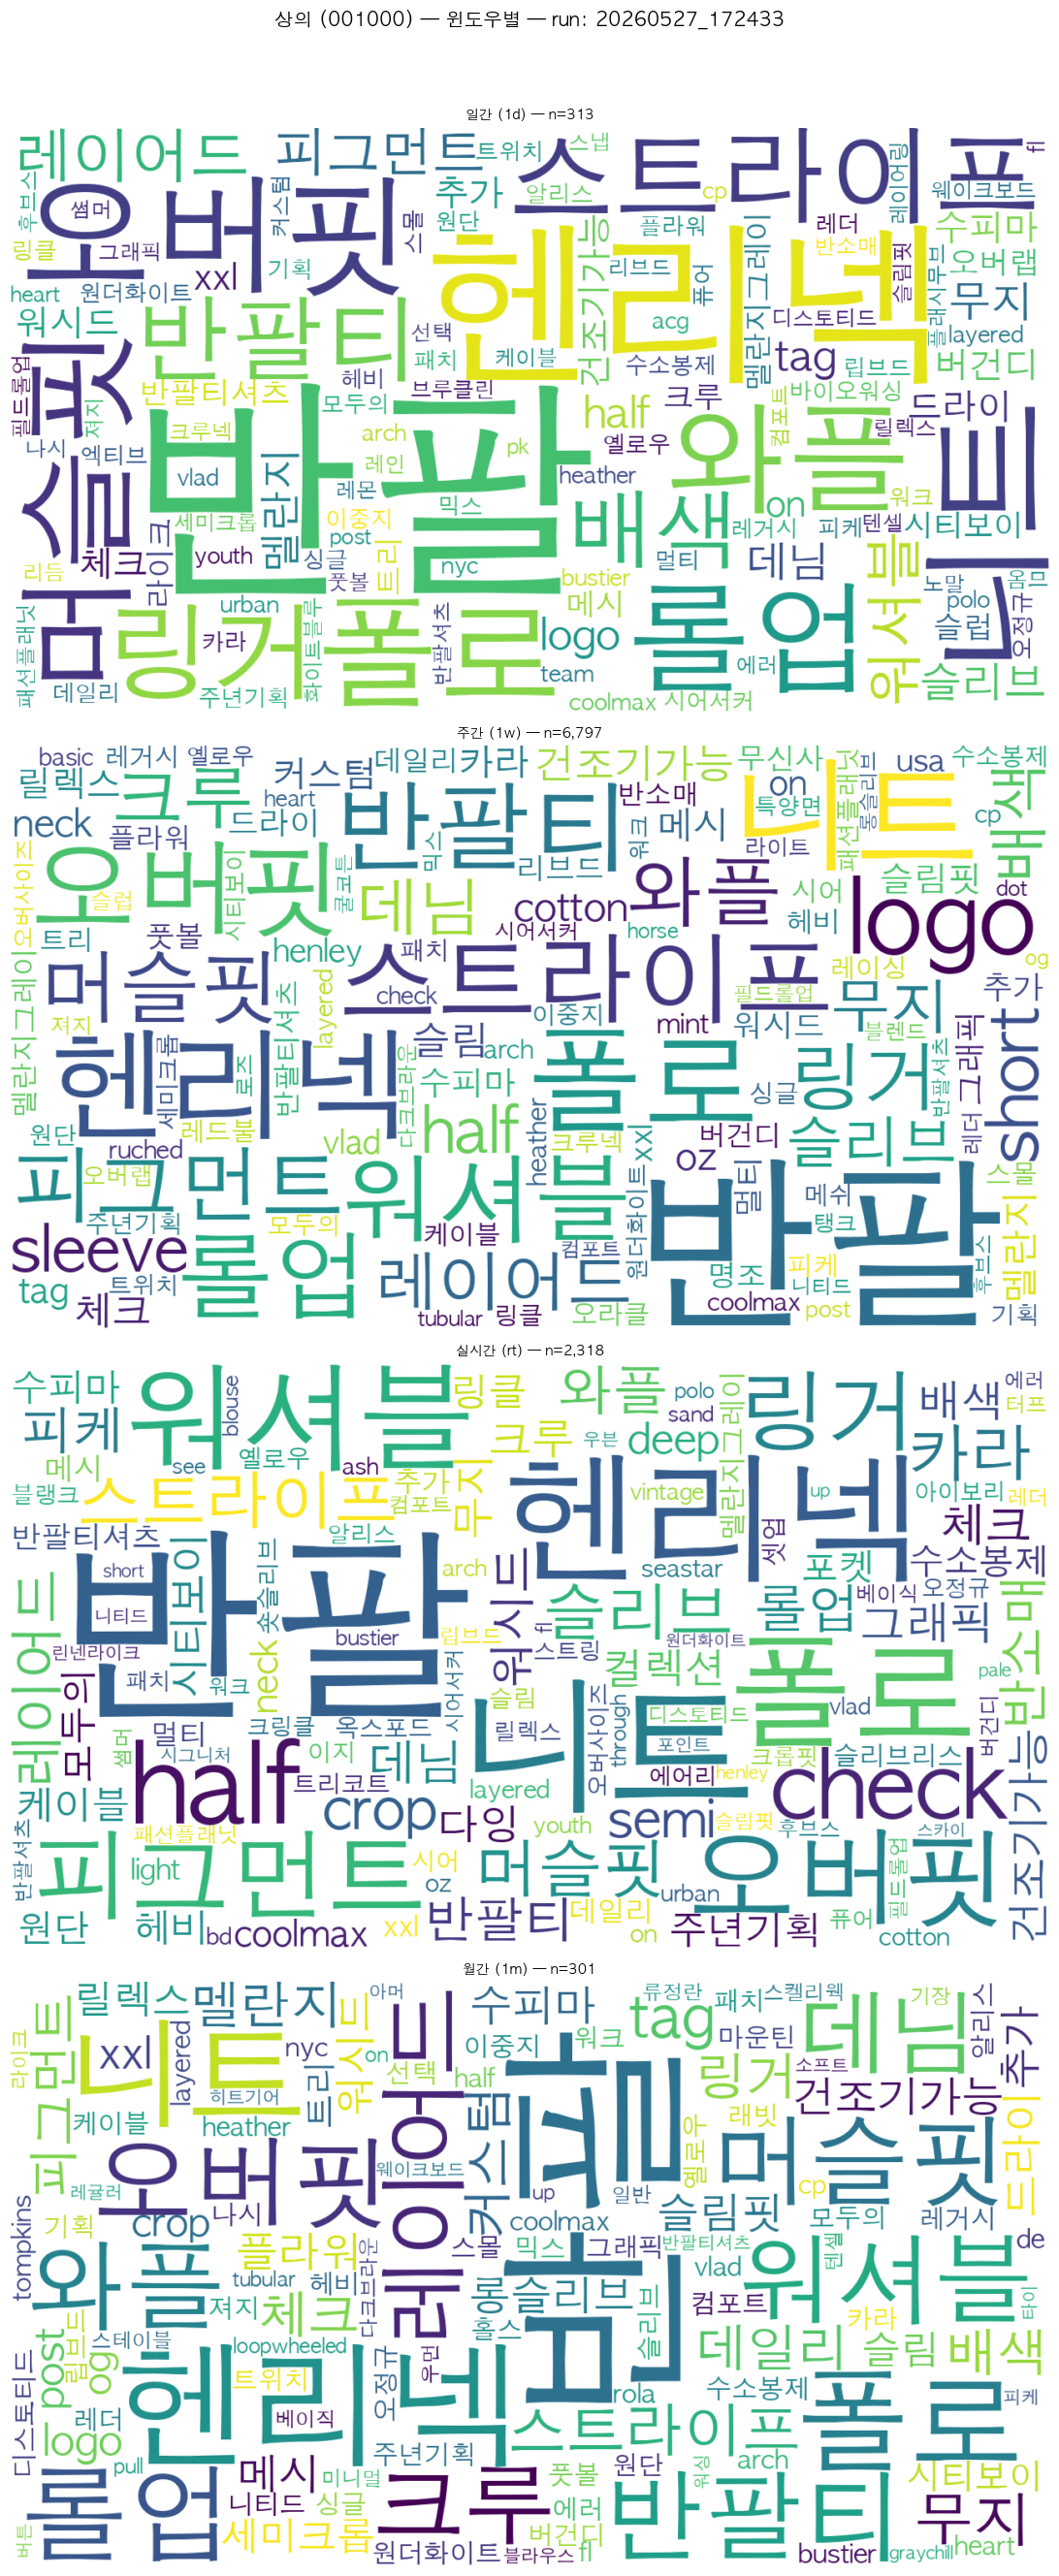

In [5]:
_code = "001000"
if _code not in window_panels_by_cat:
    print(f"카테고리 {_code} 데이터 없음")
else:
    _label, _panels = window_panels_by_cat[_code]
    wl.plot_wordcloud_column(
        _panels,
        suptitle=f"{_label} ({_code}) — 윈도우별 — run: {run_dir.name}",
        figsize_per_cell=COLUMN_FIGSIZE,
        save_path=OUTPUT_DIR / f"{run_dir.name}_{_code}_by_window.png",
    )

### 아우터 (`002000`)


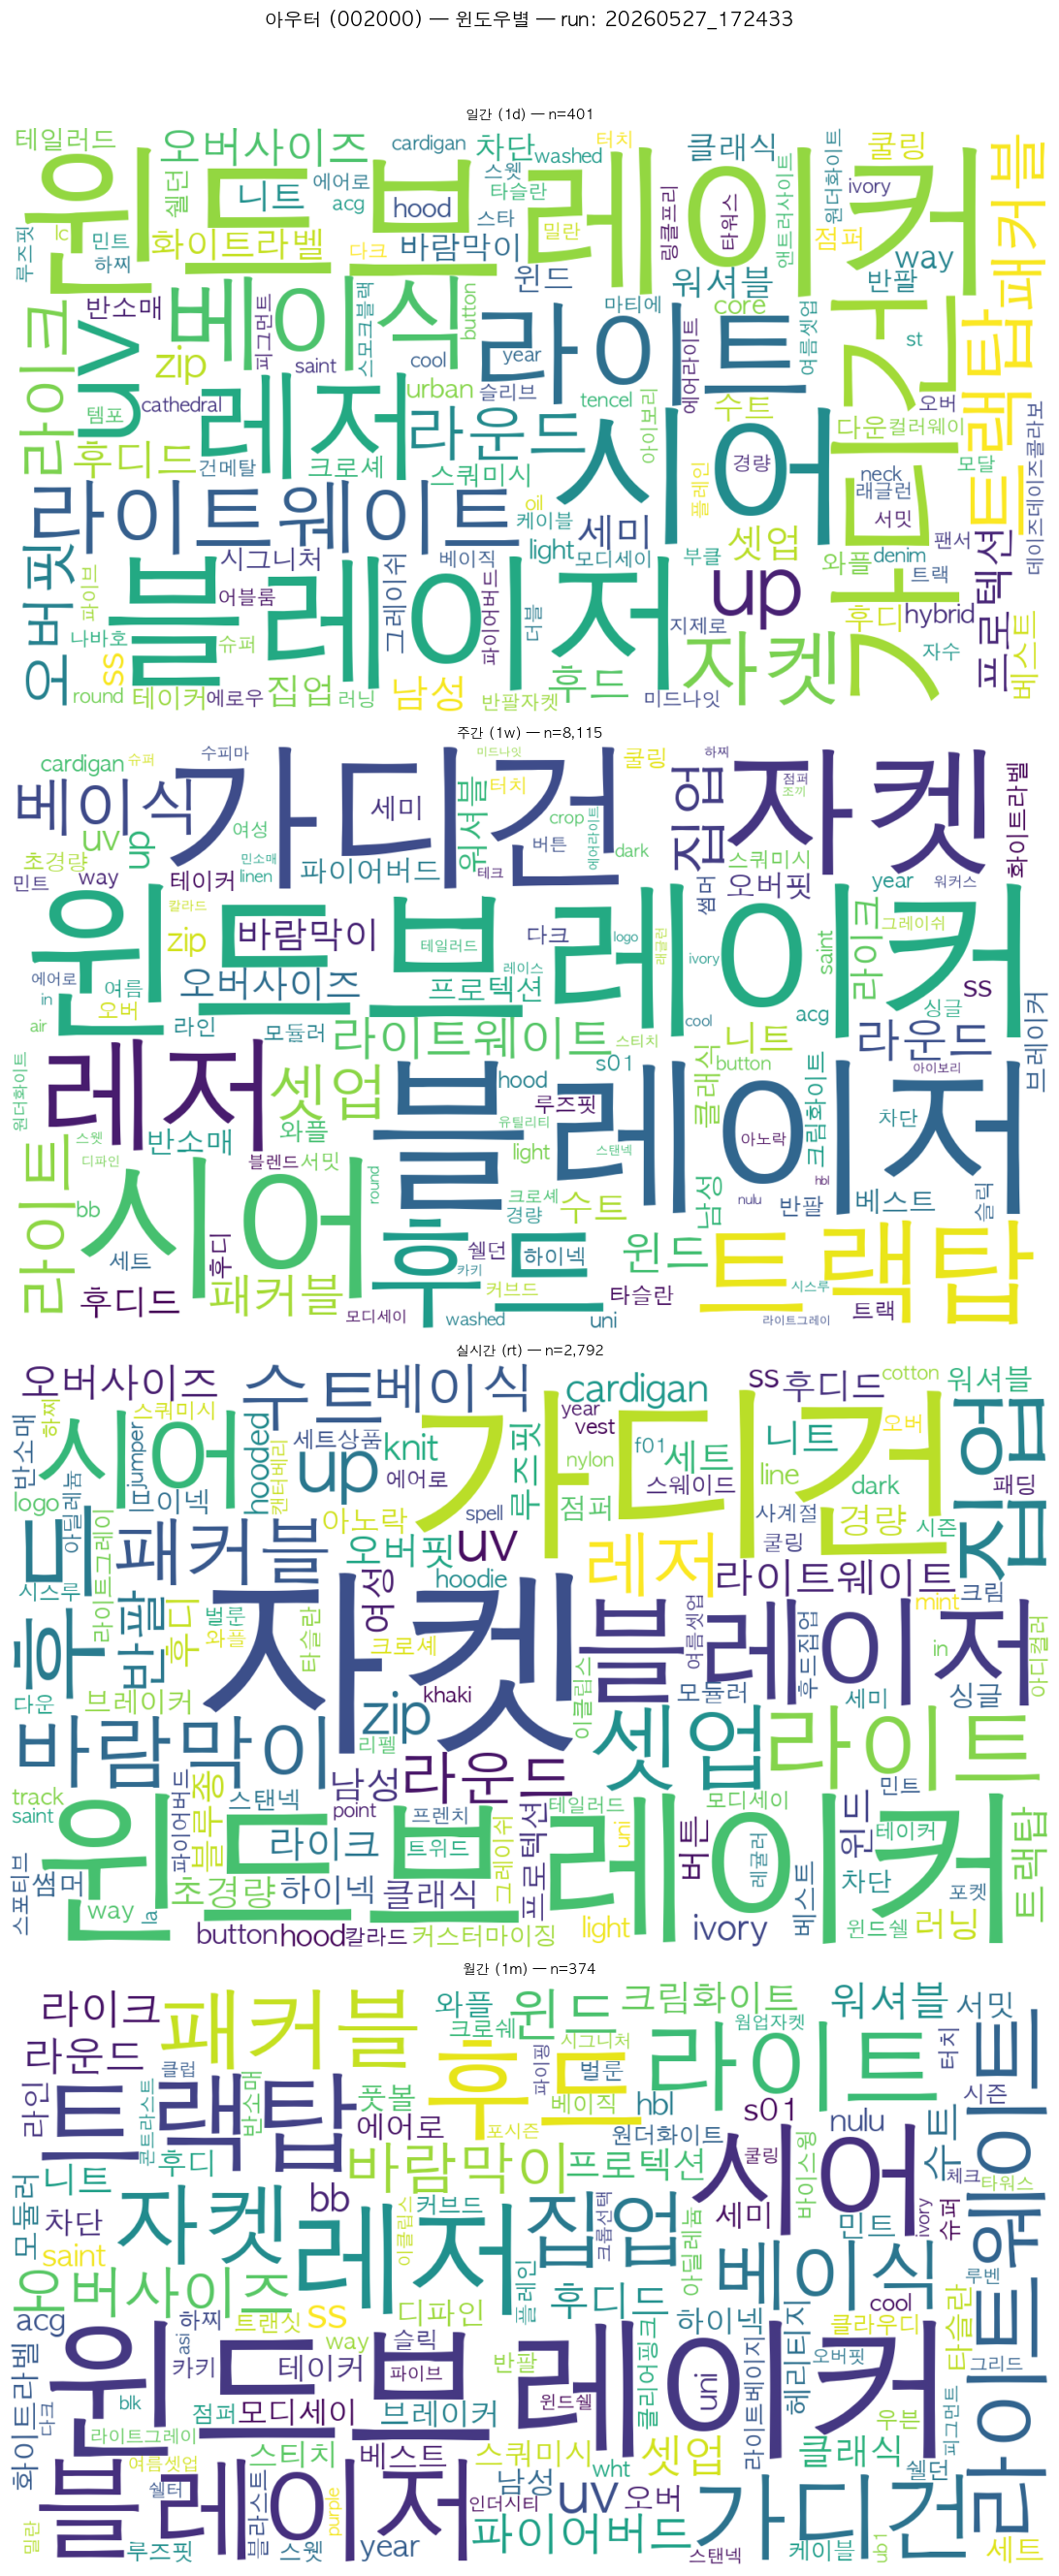

In [6]:
_code = "002000"
if _code not in window_panels_by_cat:
    print(f"카테고리 {_code} 데이터 없음")
else:
    _label, _panels = window_panels_by_cat[_code]
    wl.plot_wordcloud_column(
        _panels,
        suptitle=f"{_label} ({_code}) — 윈도우별 — run: {run_dir.name}",
        figsize_per_cell=COLUMN_FIGSIZE,
        save_path=OUTPUT_DIR / f"{run_dir.name}_{_code}_by_window.png",
    )

### 바지 (`003000`)


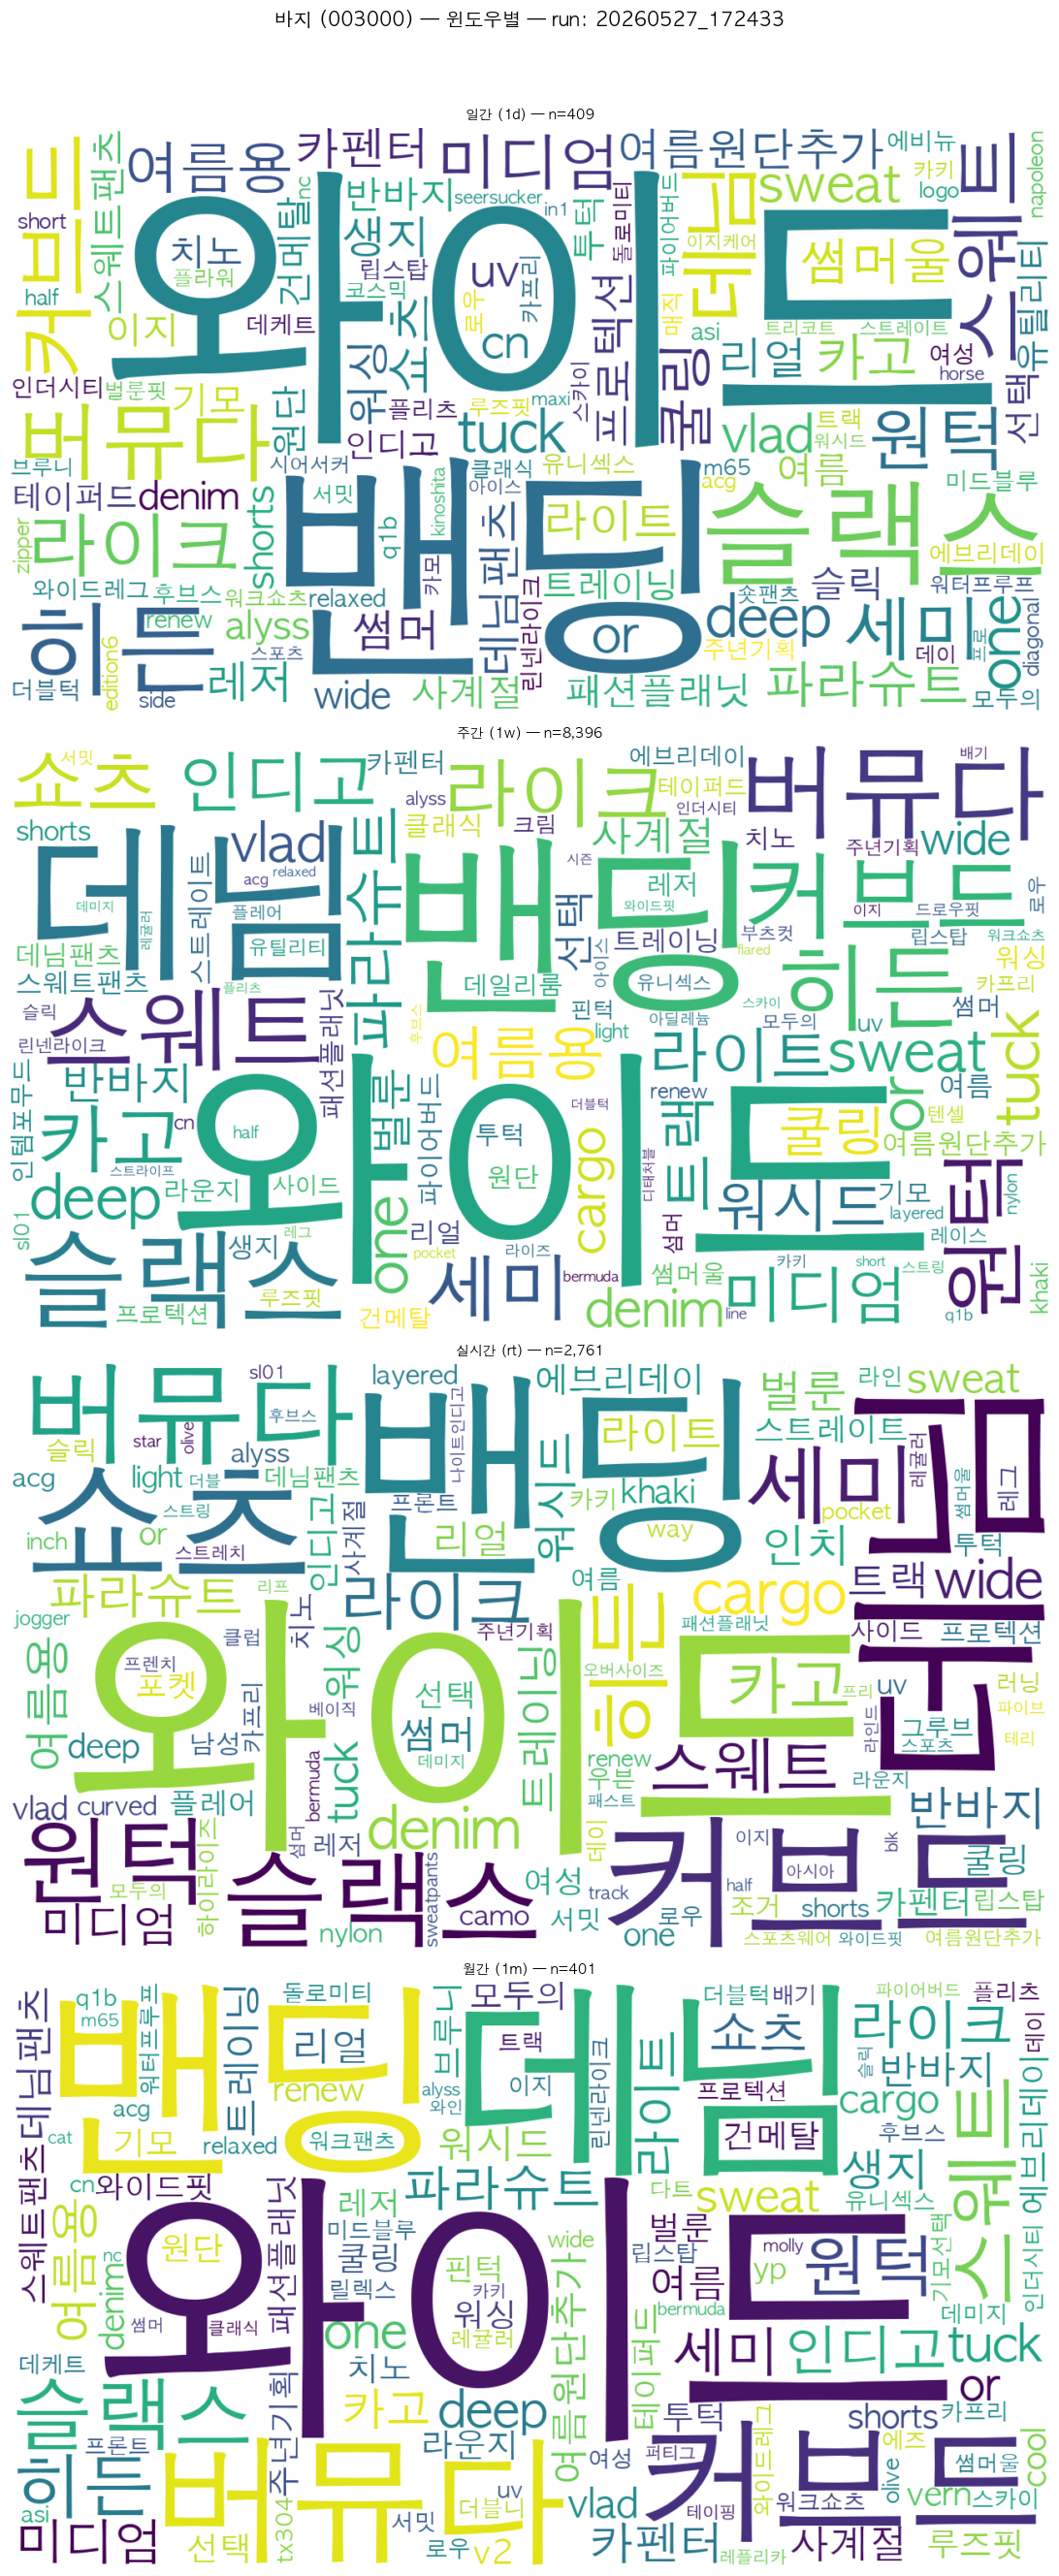

In [7]:
_code = "003000"
if _code not in window_panels_by_cat:
    print(f"카테고리 {_code} 데이터 없음")
else:
    _label, _panels = window_panels_by_cat[_code]
    wl.plot_wordcloud_column(
        _panels,
        suptitle=f"{_label} ({_code}) — 윈도우별 — run: {run_dir.name}",
        figsize_per_cell=COLUMN_FIGSIZE,
        save_path=OUTPUT_DIR / f"{run_dir.name}_{_code}_by_window.png",
    )

### 가방 (`004000`)


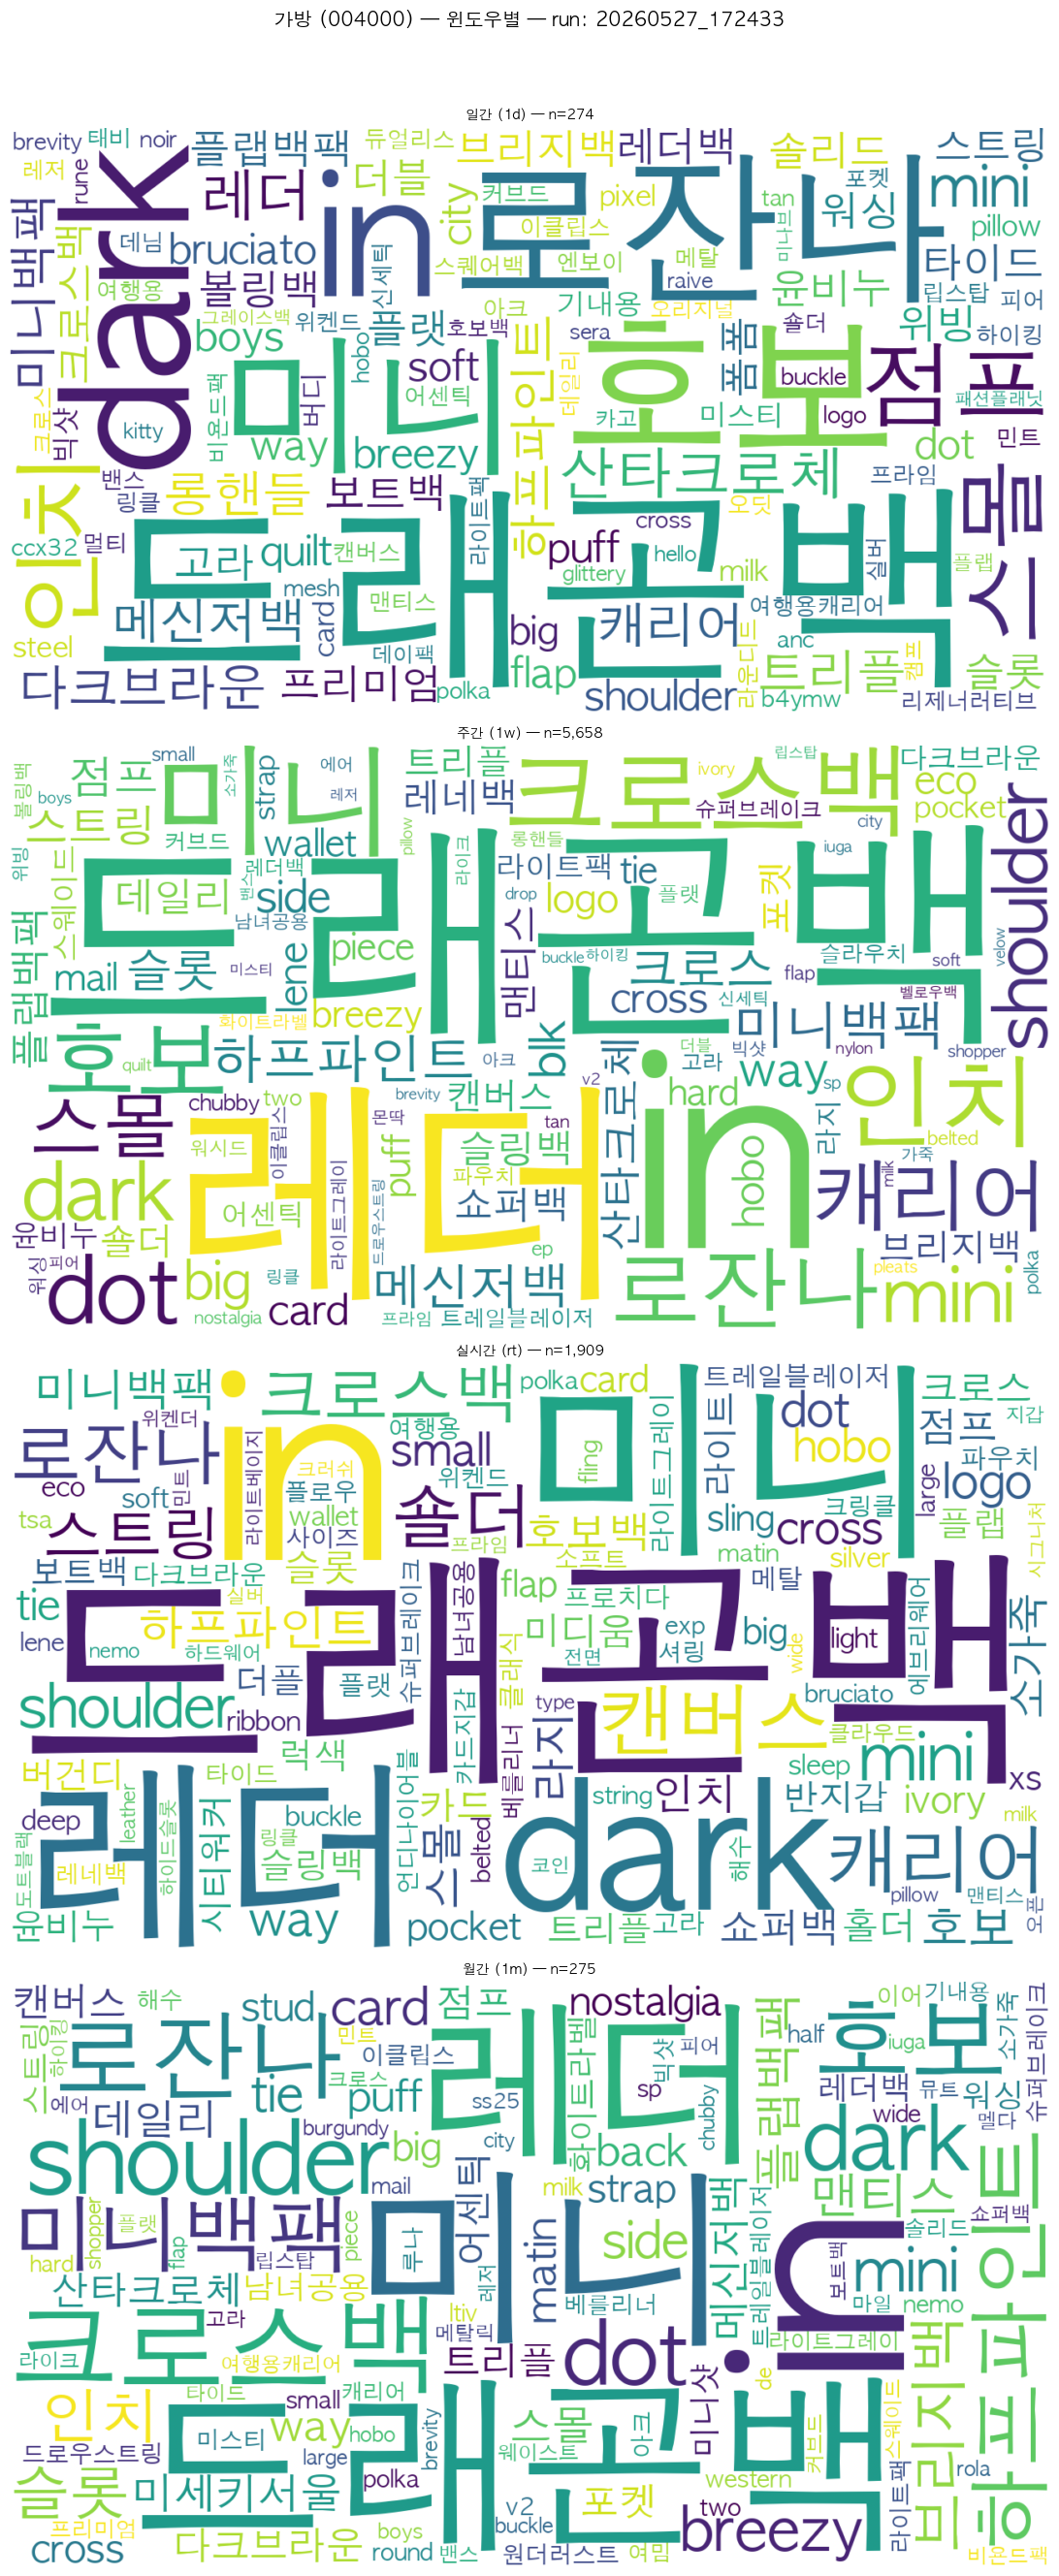

In [8]:
_code = "004000"
if _code not in window_panels_by_cat:
    print(f"카테고리 {_code} 데이터 없음")
else:
    _label, _panels = window_panels_by_cat[_code]
    wl.plot_wordcloud_column(
        _panels,
        suptitle=f"{_label} ({_code}) — 윈도우별 — run: {run_dir.name}",
        figsize_per_cell=COLUMN_FIGSIZE,
        save_path=OUTPUT_DIR / f"{run_dir.name}_{_code}_by_window.png",
    )

## 윈도우별 TOP 키워드 테이블 (선택)


In [9]:
TOP_N = 15
FOCUS_CATEGORY_CODE = "001000"

if FOCUS_CATEGORY_CODE not in window_panels_by_cat:
    print(f"{FOCUS_CATEGORY_CODE} 없음")
else:
    _label, _panels = window_panels_by_cat[FOCUS_CATEGORY_CODE]
    for subtitle, ctr in _panels:
        print(f"\n=== {_label} / {subtitle} TOP {TOP_N} ===")
        display(pd.DataFrame(ctr.most_common(TOP_N), columns=["token", "count"]))


=== 상의 / 일간 (1d) TOP 15 ===


,token,count
0,반팔,33
1,헨리넥,16
2,니트,9
3,오버핏,8
4,롤업,7
5,와플,7
6,폴로,7
7,머슬핏,7
8,스트라이프,6
9,링거,6



=== 상의 / 주간 (1w) TOP 15 ===


,token,count
0,반팔,538
1,니트,174
2,헨리넥,165
3,폴로,149
4,오버핏,117
5,스트라이프,106
6,logo,106
7,반팔티,104
8,워셔블,103
9,롤업,100



=== 상의 / 실시간 (rt) TOP 15 ===


,token,count
0,반팔,196
1,니트,81
2,헨리넥,73
3,폴로,55
4,워셔블,50
5,half,41
6,오버핏,41
7,피그먼트,35
8,check,30
9,링거,29



=== 상의 / 월간 (1m) TOP 15 ===


,token,count
0,반팔,32
1,헨리넥,12
2,니트,9
3,폴로,8
4,롤업,7
5,와플,6
6,반팔티,6
7,머슬핏,6
8,오버핏,6
9,워셔블,6
